In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
from water_sim_basic import (
    generate_polyhedron,
    compute_vertex_normals_and_volume,
    step,
    )
    
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

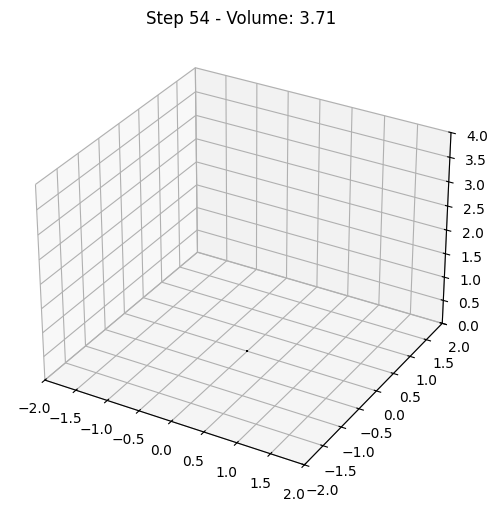

KeyboardInterrupt: 

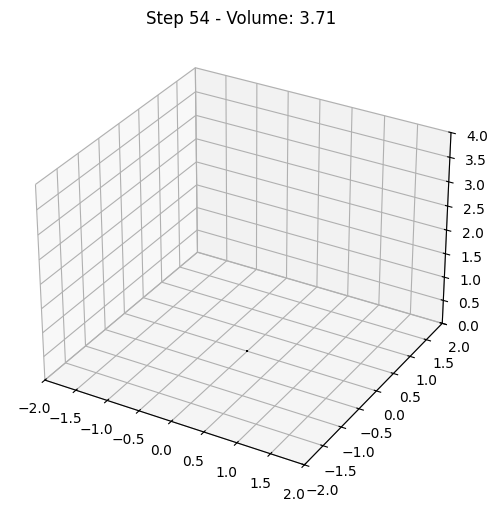

In [2]:
# --- Initialization ---
n_verts = 50
radius = 1.0
x, faces, neighbours = generate_polyhedron(n_vertices=n_verts, radius=radius) #

# Drop from Z=1 (Center is at 0, so we add 2 to clear the floor)
x[:, 2] += 1.50 
v = np.zeros_like(x)

# Calculate the 'ideal' volume to maintain
_, V_initial = compute_vertex_normals_and_volume(x, faces) #

dt = 0.00001
num_steps = 1000

# --- Plotting Setup ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for s in range(num_steps):
    # Update Physics
    x, v = step(x, v, faces, neighbours, V_initial, dt)
    
    # Visualization
    ax.clear()
    
    # Create triangle mesh for plotting
    poly = Poly3DCollection(x[faces], alpha=0.5, edgecolor='k', facecolors='cyan')
    ax.add_collection3d(poly)
    
    # Fix the viewing window
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_zlim(0, 4)
    ax.set_title(f"Step {s} - Volume: {V_initial:.2f}")
    
    # Refresh the notebook display
    display.clear_output(wait=True)
    display.display(plt.gcf())
    
plt.close() # Prevents extra static plot from showing